# Write Benchmark: Random Node Writes vs Cluster Size

This benchmark:

- starts a local cluster via `start-cluster.sh`
- waits for convergence using the same `/cluster` `total_nodes` check used by the script
- writes a fixed payload to **random nodes**
- runs for cluster sizes **1..10**
- compares eviction strategies: **FIFO**, **LRU**, **NONE**
- sets storage size to **10x payload size** for every run

> **Note:** Running this notebook starts/stops real local QaD processes repeatedly.


In [5]:
from pathlib import Path
import csv
import json
import math
import os
import random
import signal
import statistics
import subprocess
import time
import urllib.error
import urllib.request

import matplotlib.pyplot as plt

# Resolve project root (notebook is expected in benchmarks/)
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "start-cluster.sh").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

START_CLUSTER_SCRIPT = PROJECT_ROOT / "start-cluster.sh"
QAD_BINARY = PROJECT_ROOT / "qad"

BASE_HTTP_PORT = 8090
JOIN_TIMEOUT_SECONDS = 60

# Benchmark configuration
PAYLOAD = b"x" * 1024  # fixed payload: 1 KiB
PAYLOAD_SIZE = len(PAYLOAD)
STORAGE_SIZE = PAYLOAD_SIZE * 10  # required: 10x payload size

CLUSTER_SIZES = list(range(1, 11))  # size 1..10
EVICTION_ALGORITHMS = ["FIFO", "LRU", "NONE"]
WRITES_PER_CASE = 200
RNG = random.Random(42)

print(f"Project root: {PROJECT_ROOT}")
print(f"Payload size: {PAYLOAD_SIZE} bytes")
print(f"Storage size: {STORAGE_SIZE} bytes")

Project root: /home/marvin/dev/qad
Payload size: 1024 bytes
Storage size: 10240 bytes


In [6]:
def ensure_qad_binary() -> None:
    if QAD_BINARY.exists() and os.access(QAD_BINARY, os.X_OK):
        return

    print("Building qad binary via `make build`...")
    subprocess.run(["make", "build"], cwd=PROJECT_ROOT, check=True)


def http_get_json(url: str, timeout: float = 2.0) -> dict | None:
    try:
        with urllib.request.urlopen(url, timeout=timeout) as resp:
            if resp.status != 200:
                return None
            return json.loads(resp.read().decode("utf-8"))
    except Exception:
        return None


def wait_for_cluster_convergence(
    expected_nodes: int, timeout_seconds: int = JOIN_TIMEOUT_SECONDS
) -> bool:
    """
    Same readiness logic as start-cluster.sh: each node's /cluster endpoint
    must report total_nodes == expected_nodes.
    """
    ports = [BASE_HTTP_PORT + i for i in range(expected_nodes)]
    deadline = time.time() + timeout_seconds

    while time.time() < deadline:
        all_ready = True

        for port in ports:
            data = http_get_json(f"http://127.0.0.1:{port}/cluster", timeout=1.5)
            if not data or data.get("total_nodes") != expected_nodes:
                all_ready = False
                break

        if all_ready:
            return True

        time.sleep(1.0)

    return False


def start_cluster(
    node_count: int, eviction: str, storage_size: int
) -> subprocess.Popen:
    cmd = [
        "bash",
        str(START_CLUSTER_SCRIPT),
        str(node_count),
        "--eviction",
        eviction,
        "--storage",
        str(storage_size),
    ]
    proc = subprocess.Popen(
        cmd,
        cwd=PROJECT_ROOT,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.STDOUT,
        preexec_fn=os.setsid,
    )

    ok = wait_for_cluster_convergence(node_count)
    if not ok:
        stop_cluster(proc)
        raise RuntimeError(
            f"Cluster failed to converge for size={node_count}, eviction={eviction}"
        )

    return proc


def stop_cluster(proc: subprocess.Popen | None) -> None:
    if proc is None or proc.poll() is not None:
        return

    try:
        os.killpg(os.getpgid(proc.pid), signal.SIGTERM)
    except ProcessLookupError:
        return

    try:
        proc.wait(timeout=20)
    except subprocess.TimeoutExpired:
        try:
            os.killpg(os.getpgid(proc.pid), signal.SIGKILL)
        except ProcessLookupError:
            pass


def post_write(
    port: int, key: str, payload: bytes, timeout: float = 5.0
) -> tuple[int | None, float]:
    req = urllib.request.Request(
        url=f"http://127.0.0.1:{port}/api/{key}",
        data=payload,
        method="POST",
        headers={"Content-Type": "application/octet-stream"},
    )

    t0 = time.perf_counter()
    try:
        with urllib.request.urlopen(req, timeout=timeout) as resp:
            dt_ms = (time.perf_counter() - t0) * 1000.0
            return resp.status, dt_ms
    except urllib.error.HTTPError as e:
        dt_ms = (time.perf_counter() - t0) * 1000.0
        return e.code, dt_ms
    except Exception:
        dt_ms = (time.perf_counter() - t0) * 1000.0
        return None, dt_ms


def percentile(values: list[float], p: float) -> float:
    if not values:
        return float("nan")
    xs = sorted(values)
    idx = max(0, min(len(xs) - 1, math.ceil(p * len(xs)) - 1))
    return xs[idx]

In [7]:
ensure_qad_binary()

TMP_DIR = PROJECT_ROOT / "tmp"
TMP_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CSV = TMP_DIR / "write_benchmark_requests.csv"

fieldnames = [
    "timestamp_epoch",
    "eviction",
    "cluster_size",
    "request_index",
    "target_port",
    "key",
    "status",
    "success",
    "latency_ms",
    "payload_bytes",
    "storage_bytes",
]

total_cases = len(EVICTION_ALGORITHMS) * len(CLUSTER_SIZES)
case_num = 0

with RESULTS_CSV.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()

    for eviction in EVICTION_ALGORITHMS:
        for size in CLUSTER_SIZES:
            case_num += 1
            print(
                f"[{case_num}/{total_cases}] eviction={eviction}, cluster_size={size} ..."
            )

            proc = None
            latencies_ms: list[float] = []
            failures = 0

            try:
                proc = start_cluster(size, eviction, STORAGE_SIZE)
                ports = [BASE_HTTP_PORT + i for i in range(size)]

                for i in range(WRITES_PER_CASE):
                    port = RNG.choice(ports)  # random node target
                    key = f"{eviction.lower()}-{size}-{i}-{RNG.randrange(10**12)}"

                    status, latency_ms = post_write(port, key, PAYLOAD)
                    ok = status == 202

                    writer.writerow(
                        {
                            "timestamp_epoch": f"{time.time():.6f}",
                            "eviction": eviction,
                            "cluster_size": size,
                            "request_index": i,
                            "target_port": port,
                            "key": key,
                            "status": "" if status is None else status,
                            "success": int(ok),
                            "latency_ms": f"{latency_ms:.6f}",
                            "payload_bytes": PAYLOAD_SIZE,
                            "storage_bytes": STORAGE_SIZE,
                        }
                    )

                    if ok:
                        latencies_ms.append(latency_ms)
                    else:
                        failures += 1

                f.flush()

                success_count = len(latencies_ms)
                mean_ms = (
                    statistics.mean(latencies_ms) if latencies_ms else float("nan")
                )
                p95_ms = percentile(latencies_ms, 0.95)

                print(
                    f"  success={success_count}/{WRITES_PER_CASE}, "
                    f"mean={mean_ms:.2f} ms, p95={p95_ms:.2f} ms"
                )
            finally:
                stop_cluster(proc)

print("\nDone.")
print(f"Per-request results written to: {RESULTS_CSV}")
RESULTS_CSV

[1/30] eviction=FIFO, cluster_size=1 ...
  success=200/200, mean=0.96 ms, p95=1.36 ms
[2/30] eviction=FIFO, cluster_size=2 ...
  success=200/200, mean=0.88 ms, p95=1.23 ms
[3/30] eviction=FIFO, cluster_size=3 ...
  success=200/200, mean=1.10 ms, p95=1.76 ms
[4/30] eviction=FIFO, cluster_size=4 ...
  success=200/200, mean=0.89 ms, p95=1.14 ms
[5/30] eviction=FIFO, cluster_size=5 ...
  success=200/200, mean=0.80 ms, p95=1.07 ms
[6/30] eviction=FIFO, cluster_size=6 ...
  success=200/200, mean=1.20 ms, p95=1.96 ms
[7/30] eviction=FIFO, cluster_size=7 ...
  success=200/200, mean=0.85 ms, p95=1.06 ms
[8/30] eviction=FIFO, cluster_size=8 ...
  success=200/200, mean=0.94 ms, p95=1.28 ms
[9/30] eviction=FIFO, cluster_size=9 ...
  success=200/200, mean=0.89 ms, p95=1.19 ms
[10/30] eviction=FIFO, cluster_size=10 ...
  success=200/200, mean=0.92 ms, p95=1.21 ms
[11/30] eviction=LRU, cluster_size=1 ...
  success=200/200, mean=0.86 ms, p95=1.10 ms
[12/30] eviction=LRU, cluster_size=2 ...
  success=2

PosixPath('/home/marvin/dev/qad/tmp/write_benchmark_requests.csv')

eviction size      n    mean_ms     p50_ms     p95_ms     p99_ms
----------------------------------------------------------------
FIFO      1    200      0.961      0.991      1.359      1.466
FIFO      2    200      0.882      0.850      1.228      1.647
FIFO      3    200      1.101      1.002      1.755      2.466
FIFO      4    200      0.895      0.893      1.141      1.498
FIFO      5    200      0.802      0.832      1.075      1.203
FIFO      6    200      1.197      1.013      1.960      2.598
FIFO      7    200      0.846      0.818      1.055      1.216
FIFO      8    200      0.943      0.917      1.280      1.591
FIFO      9    200      0.891      0.891      1.187      1.423
FIFO     10    200      0.920      0.926      1.206      1.462
LRU       1    200      0.862      0.873      1.097      1.179
LRU       2    200      0.765      0.778      0.973      1.070
LRU       3    200      0.727      0.760      1.016      1.133
LRU       4    200      0.854      0.833      1.218

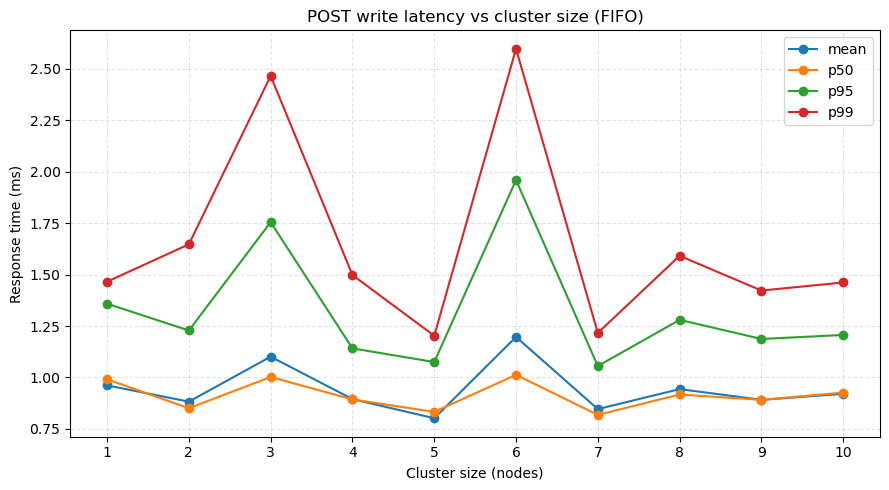

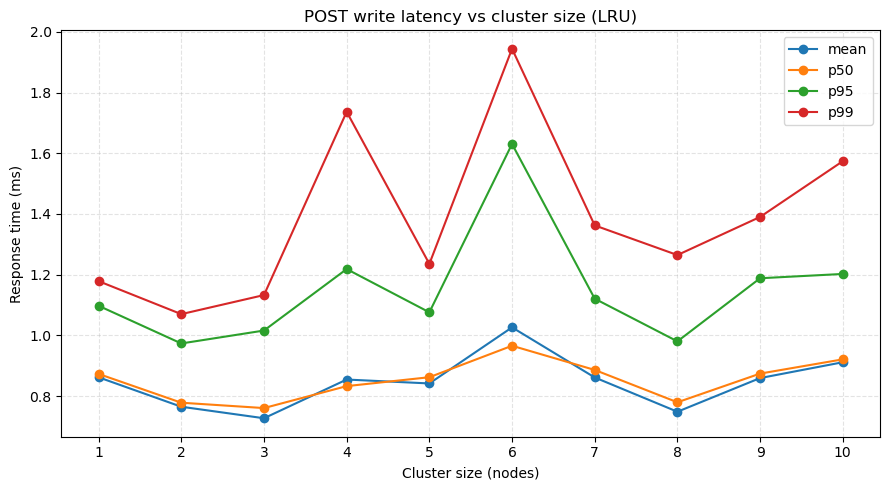

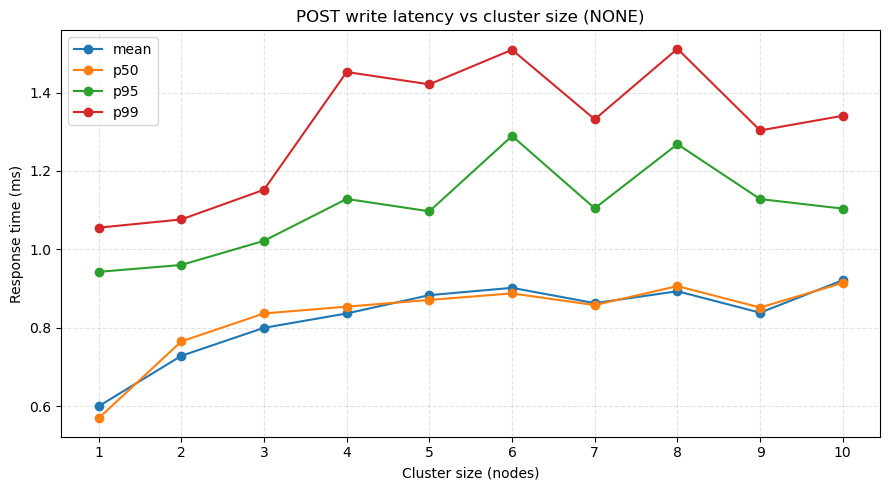

In [8]:
from collections import defaultdict

# Read per-request CSV and aggregate by (eviction, cluster_size)
agg: dict[tuple[str, int], list[float]] = defaultdict(list)

with RESULTS_CSV.open("r", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        try:
            eviction = row["eviction"]
            size = int(row["cluster_size"])
            status = int(row["status"]) if row["status"] else None
            latency_ms = float(row["latency_ms"])
        except (KeyError, ValueError):
            continue

        # Keep the same success semantics as before
        if status == 202:
            agg[(eviction, size)].append(latency_ms)


# Build summary rows
summary_rows: list[dict] = []
for eviction in EVICTION_ALGORITHMS:
    for size in CLUSTER_SIZES:
        values = agg.get((eviction, size), [])
        summary_rows.append(
            {
                "eviction": eviction,
                "cluster_size": size,
                "count": len(values),
                "mean_ms": statistics.mean(values) if values else float("nan"),
                "p50_ms": percentile(values, 0.50),
                "p95_ms": percentile(values, 0.95),
                "p99_ms": percentile(values, 0.99),
            }
        )


# Print compact table
header = (
    f"{'eviction':<6} {'size':>4} {'n':>6} {'mean_ms':>10} "
    f"{'p50_ms':>10} {'p95_ms':>10} {'p99_ms':>10}"
)
print(header)
print("-" * len(header))
for r in summary_rows:
    print(
        f"{r['eviction']:<6} {r['cluster_size']:>4} {r['count']:>6} "
        f"{r['mean_ms']:>10.3f} {r['p50_ms']:>10.3f} "
        f"{r['p95_ms']:>10.3f} {r['p99_ms']:>10.3f}"
    )


# 3 plots: one for each eviction strategy, each with 4 lines
for eviction in EVICTION_ALGORITHMS:
    rows = [r for r in summary_rows if r["eviction"] == eviction]
    rows.sort(key=lambda x: x["cluster_size"])

    xs = [r["cluster_size"] for r in rows]
    mean_line = [r["mean_ms"] for r in rows]
    p50_line = [r["p50_ms"] for r in rows]
    p95_line = [r["p95_ms"] for r in rows]
    p99_line = [r["p99_ms"] for r in rows]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(xs, mean_line, marker="o", label="mean")
    ax.plot(xs, p50_line, marker="o", label="p50")
    ax.plot(xs, p95_line, marker="o", label="p95")
    ax.plot(xs, p99_line, marker="o", label="p99")

    ax.set_title(f"POST write latency vs cluster size ({eviction})")
    ax.set_xlabel("Cluster size (nodes)")
    ax.set_ylabel("Response time (ms)")
    ax.set_xticks(CLUSTER_SIZES)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend()
    plt.tight_layout()
    plt.show()